# Stage 1: Evaluation and Backtesting Demo 
**PG-S2-36 - Automatic Discovery of Interpretable Financial Factors**

Abu Wakkas Bastob | 20 September 2026

This notebook walks through the entire Stage 1 pipeline step by step: 
* Loading data 
* Building features 
* Splitting by time
* Training models
* Evaluating 
* Backtesting



In [2]:
# Section 1: Setup for the right environment 

import sys
import numpy as np
import pandas as pd
import sklearn

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.9
numpy: 2.5.3
pandas: 2.3.3
scikit-learn: 1.9.1


In [3]:
import sys
print(sys.executable)

/Users/bastobsmacm2pro/Documents/SemanticMLPFinance/.venv/bin/python3


## Load the Dataset

This is Taiyu's cleaned, aligned dataset: five years of daily price data for AAPL and three related tickers (MSFT, NVDA, QQQ), sourced from yahoo Finance and checked for missing values, duplicates and invalid prices before being saved here.

In [4]:
# Section 2: Load the cleaned, aligned dataset
raw_data = pd.read_csv('data/processed/aligned_daily_ohlcv_5y.csv')

print("Shape:", raw_data.shape)
raw_data.head()

Shape: (5012, 7)


,Ticker,Date,Open,High,Low,Close,Volume
0,AAPL,2021-08-31,148.900167,149.036718,147.563898,148.090607,86453100
1,MSFT,2021-08-31,292.160127,292.236892,289.357711,289.722412,26285300
2,NVDA,2021-08-31,22.620757,22.620757,22.047639,22.311771,259850000
3,QQQ,2021-08-31,369.280898,369.348810,367.194323,368.737427,29628200
4,AAPL,2021-09-01,149.065971,151.163013,148.588034,148.753845,80313700


## Step 3: Building the Features

This turns raw prices into the interpretable signals the models will actually learn from: 


* returns > moving averages > volatility > volume pattern (Built by Kevin)
* This also creates the prediction target itself, whether AAPL closes higher the next trading day.

In [5]:
# Section 3: Build features from the raw data
import sys
sys.path.insert(0, '.')  # we are importing the project's own src/ package

from src.features import build_stage1_features, FEATURE_SETS

features = build_stage1_features(raw_data)

print("Shape:", features.shape)
print("\nAvailable feature sets:")
for name, cols in FEATURE_SETS.items():
    print(f"  {name}: {len(cols)} features")

features[['Date', 'target_next_day_up'] + FEATURE_SETS['A']].head()

Shape: (1232, 26)

Available feature sets:
  A: 14 features
  B: 17 features
  C: 22 features


,Date,target_next_day_up,AAPL_return_1d,AAPL_mean_return_3d,AAPL_mean_return_5d,AAPL_mean_return_10d,AAPL_mean_return_20d,AAPL_cum_return_5d,AAPL_cum_return_10d,AAPL_cum_return_20d,AAPL_volatility_5d,AAPL_volatility_10d,AAPL_volatility_20d,AAPL_close_to_ma20,AAPL_volume_to_ma20,AAPL_daily_range
20,2021-09-29,0,0.006483,-0.009289,-0.004107,-0.004155,-0.002965,-0.020706,-0.041602,-0.059277,0.013048,0.013681,0.013381,-0.039129,-0.126838,0.016943
21,2021-09-30,1,-0.009312,-0.008877,-0.007313,-0.004926,-0.003654,-0.036301,-0.048995,-0.072192,0.011613,0.013739,0.013333,-0.044539,0.037037,0.021908
22,2021-10-01,0,0.008127,0.001766,-0.005811,-0.002278,-0.003622,-0.029063,-0.023346,-0.071591,0.013264,0.013412,0.013362,-0.033183,0.087158,0.026709
23,2021-10-04,1,-0.024606,-0.008597,-0.008622,-0.002603,-0.005064,-0.042856,-0.026585,-0.098250,0.015772,0.013953,0.014010,-0.052103,0.103775,0.028317
24,2021-10-05,1,0.014158,-0.000773,-0.001030,-0.001530,-0.005130,-0.005638,-0.016175,-0.099432,0.015775,0.014852,0.013910,-0.033553,-0.091521,0.020410


## Step 4: Splitting by Time

I use one year (2025) split by quarter: **Q1–Q2 train, Q3 validation, Q4 untouched test**.

Nothing is shuffled. Rows whose target date falls in the next period are dropped (for example, 30 June predicting 1 July). That way no label crosses from one period into the next.

In [6]:
# Section 4: Split 2025 by quarter, keeping time order
from src.data import quarterly_split

splits = quarterly_split(features, year=2025)

split_summary = pd.DataFrame({
    name: {
        'rows': len(frame),
        'first date': frame['Date'].min().date(),
        'last date': frame['Date'].max().date(),
        'last target date': frame['target_date'].max().date(),
        'share up days': round(frame['target_next_day_up'].mean(), 3),
    }
    for name, frame in splits.items()
}).T
split_summary

,rows,first date,last date,last target date,share up days
train,121,2025-01-02,2025-06-27,2025-06-30,0.504
validation,63,2025-07-01,2025-09-29,2025-09-30,0.524
test,63,2025-10-01,2025-12-30,2025-12-31,0.556


## Step 5: Training the Models

Two simple baselines and two ML models, on each feature set A / B / C:

* **Always up (majority class)** and **tomorrow = today (previous direction)**: the bars any model must beat
* **Logistic Regression** (seed 42, standardised on training data only)
* **Random Forest** (seeds 0, 1, 2: reported as mean ± standard deviation)

Models are fitted on train only. Predictions are saved for validation and test.

In [7]:
# Section 5: Train all models for 2025 and save predictions
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
from pathlib import Path
from experiments.run_stage1_training import run

_, predictions = run(Path('data/processed/aligned_daily_ohlcv_5y.csv'), Path('results/demo_2025'), year=2025)

print("Prediction rows:", len(predictions))
predictions.groupby(['split', 'experiment', 'model']).size().unstack('split')

Prediction rows: 1764


split                           test  validation
experiment model                                
A          logistic_regression    63          63
           random_forest         189         189
B          logistic_regression    63          63
           random_forest         189         189
C          logistic_regression    63          63
           random_forest         189         189
baseline   majority_class         63          63
           previous_direction     63          63

## Step 6: Evaluating (my evaluation module)

Now we mark every model's guesses: how many were right?

The main score is **balanced accuracy**:
* 0.5 = no better than flipping a coin
* above 0.5 = better than a coin
* below 0.5 = worse than a coin

In [8]:
# Section 6: Evaluate every model's predictions (my evaluation code, written out in full)
import numpy as np
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Part 1: check the prediction file before scoring anything
def check_predictions(preds):
    preds = preds.copy()
    preds['Date'] = pd.to_datetime(preds['Date'])
    preds['target_date'] = pd.to_datetime(preds['target_date'])

    # 1. Every row must predict a later day than the day it was made
    assert (preds['target_date'] > preds['Date']).all(), "target_date must come after Date"

    # 2. Labels and predictions must be 0 or 1; probabilities between 0 and 1
    assert preds['actual'].isin([0, 1]).all() and preds['predicted'].isin([0, 1]).all(), "labels must be 0/1"
    assert preds['probability_up'].between(0, 1).all(), "probabilities must be in [0, 1]"

    # 3. Correct seeds: LR = 42, RF = 0/1/2, baselines have no seed
    lr = preds['model'] == 'logistic_regression'
    rf = preds['model'] == 'random_forest'
    base = preds['experiment'] == 'baseline'
    assert (preds.loc[lr, 'seed'] == 42).all(), "LR must use seed 42"
    assert preds.loc[rf, 'seed'].isin([0, 1, 2]).all(), "RF must use seeds 0, 1, 2"
    assert preds.loc[base, 'seed'].isna().all(), "baselines have no seed"

    # 4. No day predicted twice by the same run
    run_keys = ['split', 'experiment', 'model', 'seed']
    assert not preds.duplicated(run_keys + ['Date']).any(), "a day appears twice in one run"

    # 5. Fair comparison: within each split, every run predicted the SAME days with the SAME true answers
    for split, part in preds.groupby('split'):
        reference = None
        for _, run_rows in part.groupby(run_keys, dropna=False):
            days = run_rows.sort_values('Date')[['Date', 'actual']].reset_index(drop=True)
            if reference is None:
                reference = days
            assert days.equals(reference), f"runs in {split} do not cover the same days"

    # 6. Validation must end before test starts (no overlap)
    assert preds.loc[preds.split == 'validation', 'target_date'].max() < preds.loc[preds.split == 'test', 'Date'].min()
    return preds

checked = check_predictions(predictions)
print("All checks passed:", len(checked), "predictions")



# Part 2: the six scores for one run
def six_scores(actual, predicted, probability):
    return {
        'accuracy':          accuracy_score(actual, predicted),            # share of days right
        'balanced_accuracy': balanced_accuracy_score(actual, predicted),   # average of (right on up days, right on down days)
        'auc':               roc_auc_score(actual, probability),           # do up days get higher probabilities than down days?
        'precision':         precision_score(actual, predicted, zero_division=0),  # when it said "up", how often right
        'recall':            recall_score(actual, predicted, zero_division=0),     # of real up days, how many caught
        'f1':                f1_score(actual, predicted, zero_division=0),         # balance of precision and recall
    }

# Score every single run (each RF seed separately)
rows = []
for (split, experiment, model, seed), run_rows in checked.groupby(['split', 'experiment', 'model', 'seed'], dropna=False):
    scores = six_scores(run_rows['actual'], run_rows['predicted'], run_rows['probability_up'])
    rows.append({'split': split, 'experiment': experiment, 'model': model, 'seed': seed,
                 'days': len(run_rows), **scores})
per_run = pd.DataFrame(rows)




# Part 3: average the 3 Random Forest runs (mean and spread)
metric_names = ['accuracy', 'balanced_accuracy', 'auc', 'precision', 'recall', 'f1']
comparison = (per_run.groupby(['split', 'experiment', 'model'])[metric_names]
                     .agg(['mean', 'std']))
comparison.columns = [f"{metric}_{stat}" for metric, stat in comparison.columns]
comparison = comparison.reset_index()

# Show the test results (Q4 2025)
cols = ['split', 'experiment', 'model', 'accuracy_mean', 'balanced_accuracy_mean',
        'balanced_accuracy_std', 'auc_mean', 'f1_mean']
comparison.loc[comparison.split == 'test', cols].round(3)

All checks passed: 1764 predictions


,split,experiment,model,accuracy_mean,balanced_accuracy_mean,balanced_accuracy_std,auc_mean,f1_mean
0,test,A,logistic_regression,0.413,0.461,NaN,0.558,0.051
1,test,A,random_forest,0.460,0.504,0.000,0.572,0.190
2,test,B,logistic_regression,0.413,0.454,NaN,0.534,0.140
3,test,B,random_forest,0.413,0.449,0.030,0.554,0.189
4,test,C,logistic_regression,0.381,0.411,NaN,0.478,0.204
5,test,C,random_forest,0.402,0.438,0.022,0.470,0.173
6,test,baseline,majority_class,0.556,0.500,NaN,0.500,0.714
7,test,baseline,previous_direction,0.540,0.532,NaN,0.532,0.592


* All checks passed: every model predicted the same 63 days, so the comparison is fair.
* The best simple rule, "tomorrow = today", scores **0.532** balanced accuracy.
* The best model, Random Forest with Apple-only data (A), scores **0.504**, a coin flip. No model beats the simple rule.
* Adding the market (B) and peers (C) made results **worse**.
* "Always up" has the highest plain accuracy (0.556) only because Apple went up on 55.6% of Q4 days. Balanced accuracy catches this and gives it 0.5.
* std = how much the 3 Random Forest runs differed. NaN = only one run, so there's no spread.

## Step 7: Backtesting (my work)

**The question:** if we had invested money using the model's guesses, would we have made money?

1. **Pick one model** using the **validation** quarter (Q3) only, never the test quarter
2. **Simulate Q4:** each day, if the model says "up", hold Apple until the next day. If it says "down", stay in cash
3. **Compare** with simply buying Apple and holding it all quarter

Assumptions (optimistic, research only): trade at the closing price, no fees, no short-selling.

In [9]:
# Section 7: Backtest (my backtesting code, written out in full)

# Part 1: choose ONE model using the validation quarter only
val = comparison[comparison.split == 'validation'].sort_values(
    ['balanced_accuracy_mean', 'experiment', 'model'], ascending=[False, True, True])
best = val.iloc[0]
seed = {'logistic_regression': 42, 'random_forest': 0}.get(best['model'])   # RF: seed 0 fixed in advance
print(f"Chosen on validation (Q3): experiment {best['experiment']}, {best['model']}, "
      f"validation balanced accuracy {best['balanced_accuracy_mean']:.3f}")

# Take that model's Q4 test guesses
mask = (checked.split == 'test') & (checked.experiment == best['experiment']) & (checked.model == best['model'])
mask &= checked.seed.isna() if seed is None else (checked.seed == seed)
trades = checked[mask].sort_values('Date')[['Date', 'target_date', 'actual', 'predicted']].reset_index(drop=True)

# Part 2: get Apple's real return for each day
aapl_px = raw_data[raw_data.Ticker == 'AAPL'][['Date', 'Close']].copy()
aapl_px['Date'] = pd.to_datetime(aapl_px['Date'])
aapl_px = aapl_px.sort_values('Date').reset_index(drop=True)
aapl_px['next_date'] = aapl_px['Date'].shift(-1)
aapl_px['next_close'] = aapl_px['Close'].shift(-1)
trades = trades.merge(aapl_px, on='Date', how='left')

# Safety checks: the next close really is the target day, and the labels agree with real prices
assert (trades['target_date'] == trades['next_date']).all(), "target day does not match the next trading day"
trades['aapl_return'] = trades['next_close'] / trades['Close'] - 1
assert (trades['actual'] == (trades['aapl_return'] > 0).astype(int)).all(), "labels disagree with prices"

# Part 3: simulate the strategy
# Predicted up (1) -> hold Apple until the next close. Predicted down (0) -> stay in cash (earn 0).
trades['position'] = trades['predicted']
trades['strategy_return'] = trades['aapl_return'] * trades['position']
trades['strategy_value'] = (1 + trades['strategy_return']).cumprod()    # what $1 grows to
trades['buy_hold_value'] = (1 + trades['aapl_return']).cumprod()        # just holding Apple every day

# Part 4: performance measures
def performance(returns):
    value = np.concatenate([[1.0], (1 + returns).cumprod()])               # start with $1
    drawdown = value / np.maximum.accumulate(value) - 1                    # fall from the highest point so far
    sharpe = np.sqrt(252) * returns.mean() / returns.std(ddof=1)           # return per unit of risk, per year
    return {'total_return': value[-1] - 1, 'max_drawdown': drawdown.min(), 'sharpe': sharpe}

print(f"Test window: {trades.Date.iloc[0].date()} to {trades.target_date.iloc[-1].date()} "
      f"({len(trades)} days, in the market on {int(trades.position.sum())} days)\n")
backtest_summary = pd.DataFrame([
    {'strategy': 'model (long when it predicts up, else cash)', **performance(trades['strategy_return'])},
    {'strategy': 'buy and hold Apple', **performance(trades['aapl_return'])},
])
backtest_summary.round(4)

Chosen on validation (Q3): experiment B, logistic_regression, validation balanced accuracy 0.576
Test window: 2025-10-01 to 2025-12-31 (63 days, in the market on 8 days)



,strategy,total_return,max_drawdown,sharpe
0,"model (long when it predicts up, else cash)",-0.0072,-0.0220,-0.5299
1,buy and hold Apple,0.0653,-0.0532,1.5298



* The model was **chosen on Q3**: LR with pack B scored best there (0.576). It was **not** chosen by looking at Q4.
* In Q4 it predicted "up" on only **8 of 63 days**, so it sat in cash most of the time.
* **Model: −0.7%.** Simply holding Apple: **+6.5%**. The model lost money while Apple went up.
* Its worst fall was smaller (−2.2% vs −5.3%), but only because it was mostly out of the market.
* Sharpe (return for the risk taken): model −0.53, buy-and-hold +1.53.
* **Conclusion:** trading on these predictions would not have been worth it in Q4 2025.

## Step 8: Testing Beyond 2025

One test quarter is only 63 days, too small to trust. So I repeat **exactly the same process** on four different years: 2022, 2023, 2024 and 2025.

For each year:
* Q1–Q2 train, Q3 validation, Q4 test (same split rule)
* Train the same models (Step 5)
* Check and score them (Step 6)
* Backtest the model chosen on Q3 (Step 7)

**If a model really works, it should do well in every year, not just one.**

In [10]:
# Section 8: Repeat the whole pipeline on 2022, 2023, 2024 and 2025
# Uses: Kevin's run() for training (Step 5), and my check_predictions, six_scores, performance (Steps 6-7)
from pathlib import Path
from experiments.run_stage1_training import run

def score_runs(preds):
    """Step 6 for one year: score every run, then average the 3 RF seeds."""
    rows = []
    for (split, experiment, model, seed), run_rows in preds.groupby(['split', 'experiment', 'model', 'seed'], dropna=False):
        rows.append({'split': split, 'experiment': experiment, 'model': model, 'seed': seed,
                     **six_scores(run_rows['actual'], run_rows['predicted'], run_rows['probability_up'])})
    per_run = pd.DataFrame(rows)
    table = per_run.groupby(['split', 'experiment', 'model'])[metric_names].agg(['mean', 'std'])
    table.columns = [f"{metric}_{stat}" for metric, stat in table.columns]
    return table.reset_index()

def backtest(preds, scores):
    """Step 7 for one year: pick the best model on validation, simulate it on test."""
    best = scores[scores.split == 'validation'].sort_values(
        ['balanced_accuracy_mean', 'experiment', 'model'], ascending=[False, True, True]).iloc[0]
    seed = {'logistic_regression': 42, 'random_forest': 0}.get(best['model'])
    mask = (preds.split == 'test') & (preds.experiment == best['experiment']) & (preds.model == best['model'])
    mask &= preds.seed.isna() if seed is None else (preds.seed == seed)
    t = preds[mask].sort_values('Date')[['Date', 'target_date', 'actual', 'predicted']].merge(aapl_px, on='Date', how='left')
    assert (t['target_date'] == t['next_date']).all()
    t['aapl_return'] = t['next_close'] / t['Close'] - 1
    assert (t['actual'] == (t['aapl_return'] > 0).astype(int)).all()
    t['strategy_return'] = t['aapl_return'] * t['predicted']
    t['strategy_value'] = (1 + t['strategy_return']).cumprod()
    t['buy_hold_value'] = (1 + t['aapl_return']).cumprod()
    chosen = f"{best['experiment']} · {best['model']}"
    return t, chosen, int(t['predicted'].sum())

all_scores, all_backtests, all_daily = [], [], []
for year in [2022, 2023, 2024, 2025]:
    _, preds_y = run(Path('data/processed/aligned_daily_ohlcv_5y.csv'), Path(f'results/multi_year/{year}'), year=year)
    preds_y = check_predictions(preds_y)                       # same 6 safety checks as Step 6
    scores_y = score_runs(preds_y)                              # same scoring as Step 6
    daily_y, chosen, days_in = backtest(preds_y, scores_y)      # same backtest as Step 7
    all_scores.append(scores_y.assign(year=year))
    all_daily.append(daily_y.assign(year=year))
    all_backtests.append({'year': year, 'chosen on validation': chosen, 'test days': len(daily_y),
                          'days in market': days_in,
                          'model return': performance(daily_y['strategy_return'])['total_return'],
                          'buy & hold return': performance(daily_y['aapl_return'])['total_return']})
    print(f"{year}: done ({len(preds_y)} predictions checked and scored)")

comparison_all = pd.concat(all_scores, ignore_index=True)
daily_all = pd.concat(all_daily, ignore_index=True)
backtest_all = pd.DataFrame(all_backtests)

# Table 1: test balanced accuracy for every model, every year
by_year = comparison_all[comparison_all.split == 'test'].pivot_table(
    index=['experiment', 'model'], columns='year', values='balanced_accuracy_mean')
display(by_year.round(3))

# Table 2: the backtest for every year
backtest_all.round(4)

2022: done (1750 predictions checked and scored)
2023: done (1736 predictions checked and scored)
2024: done (1764 predictions checked and scored)
2025: done (1764 predictions checked and scored)


year                             2022   2023   2024   2025
experiment model                                          
A          logistic_regression  0.547  0.499  0.423  0.461
           random_forest        0.555  0.450  0.454  0.504
B          logistic_regression  0.547  0.585  0.423  0.454
           random_forest        0.550  0.543  0.467  0.449
C          logistic_regression  0.459  0.473  0.451  0.411
           random_forest        0.518  0.519  0.449  0.438
baseline   majority_class       0.500  0.500  0.500  0.500
           previous_direction   0.512  0.461  0.503  0.532

,year,chosen on validation,test days,days in market,model return,buy & hold return
0,2022,C · logistic_regression,62,36,-0.1195,-0.0864
1,2023,B · logistic_regression,62,39,0.1217,0.1095
2,2024,B · logistic_regression,63,37,0.0070,0.1082
3,2025,B · logistic_regression,63,8,-0.0072,0.0653


**Reading this output**

**Table 1** shows **test balanced accuracy**: each model's score on Q4 of each year. Each row is a model, and each column is a year. 0.5 means no better than flipping a coin.

*Example:* **0.585** = B · LR (Apple + market data) on Q4 2023. Apple went up on 34 days and down on 28. The model got 24 of the 34 up days right (0.706) and 13 of the 28 down days right (0.464). The average is (0.706 + 0.464) ÷ 2 = **0.585**.

* **No model wins every year.** B · LR is the best in 2023 (0.585) but one of the worst in 2024 (0.423).
* 2022 looks good for most models (around 0.55), but the next years don't repeat it.
* The simple "tomorrow = today" rule stays close to 0.5 in every year.

**Table 2** shows the backtest for each year: the model chosen on Q3, how many Q4 days it was invested, and its return compared with simply holding Apple.

* **Backtest:** the model beat buy-and-hold in only **1 of 4 years** (2023). In 2022, 2024 and 2025 it did worse than just holding Apple.
* **Conclusion:** results change a lot from year to year. A good result in one year is most likely luck, not a real pattern.

## Step 9: Visualising the Results

Tables full of numbers are hard to read, so the same Step 8 results are shown as two pictures.

**Chart 1** shows every model's test score in every year, as colours:
* **blue** = better than a coin flip (above 0.5)
* **grey** = about 0.5
* **red** = worse than a coin flip

If a model really worked, its whole row would be blue.

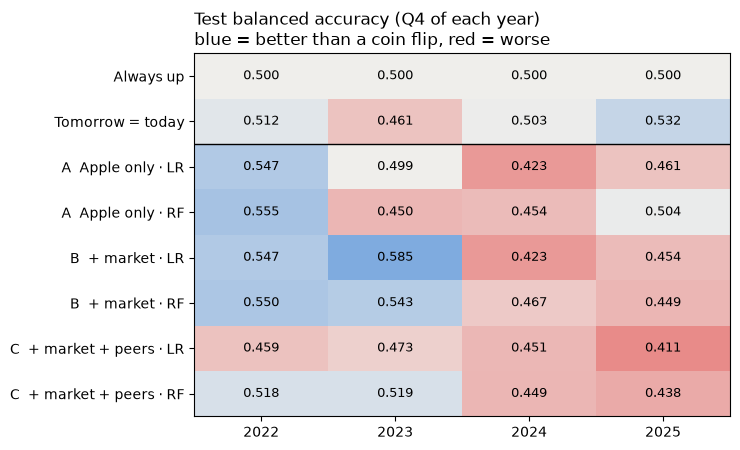

In [12]:
# Section 9a: Chart 1 - test balanced accuracy for every model and year (a colour grid)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

rows = [('baseline', 'majority_class',      'Always up'),
        ('baseline', 'previous_direction',  'Tomorrow = today'),
        ('A', 'logistic_regression', 'A  Apple only · LR'),
        ('A', 'random_forest',       'A  Apple only · RF'),
        ('B', 'logistic_regression', 'B  + market · LR'),
        ('B', 'random_forest',       'B  + market · RF'),
        ('C', 'logistic_regression', 'C  + market + peers · LR'),
        ('C', 'random_forest',       'C  + market + peers · RF')]
years = [2022, 2023, 2024, 2025]
test = comparison_all[comparison_all.split == 'test']

# Build the grid of numbers: one row per model, one column per year
grid = np.array([[test[(test.experiment == e) & (test.model == m) & (test.year == y)]['balanced_accuracy_mean'].iloc[0]
                  for y in years] for e, m, _ in rows])

# Colours: red below 0.5 (worse than a coin), grey at 0.5, blue above 0.5 (better than a coin)
colours = LinearSegmentedColormap.from_list('coin', ['#e34948', '#f0efec', '#2a78d6'])
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.imshow(grid, cmap=colours, norm=TwoSlopeNorm(vcenter=0.5, vmin=0.35, vmax=0.65), aspect='auto')

for i in range(len(rows)):                      # write each number inside its box
    for j in range(len(years)):
        ax.text(j, i, f"{grid[i, j]:.3f}", ha='center', va='center', fontsize=9)

ax.set_xticks(range(len(years)), years)
ax.set_yticks(range(len(rows)), [label for _, _, label in rows])
ax.axhline(1.5, color='black', linewidth=1)    # line between the baselines and the models
ax.set_title('Test balanced accuracy (Q4 of each year)\nblue = better than a coin flip, red = worse', loc='left')
plt.tight_layout()
plt.show()

**Chart 1**

* **No row is blue all the way across.** No model beats a coin flip every year.
* 2022 is mostly blue, then 2024 and 2025 are mostly red. The "good" year doesn't repeat.
* The darkest blue (B · LR, 2023: 0.585) sits in the same row as one of the darkest reds (2024: 0.423).
* Row C (market + peers) is red in most years. More data didn't help.

**Chart 2** 

shows the backtest for each year: what $1 grows to if you follow the model (blue), compared with simply holding Apple (orange).
If the model were useful, the blue line would end above the orange line.

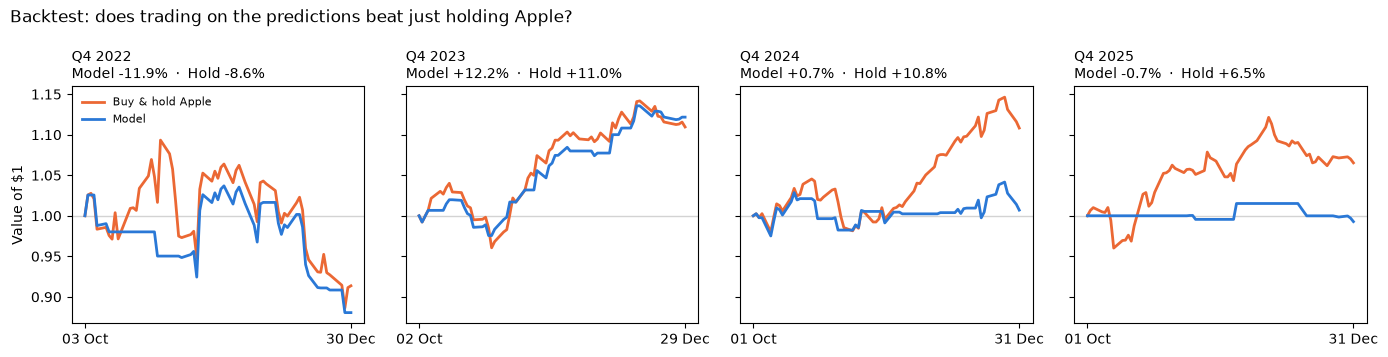

,year,chosen on validation,days in market,model return,buy & hold return
0,2022,C · logistic_regression,36,-0.1195,-0.0864
1,2023,B · logistic_regression,39,0.1217,0.1095
2,2024,B · logistic_regression,37,0.0070,0.1082
3,2025,B · logistic_regression,8,-0.0072,0.0653


In [14]:
# Section 9b: Chart 2 - what $1 grows to: model vs buy-and-hold, one panel per year
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)

for ax, year in zip(axes, years):
    d = daily_all[daily_all.year == year].sort_values('Date')
    days = [d['Date'].iloc[0]] + list(d['target_date'])           # start day + each day after a trade
    model_value = [1.0] + list(d['strategy_value'])                # start with $1
    hold_value  = [1.0] + list(d['buy_hold_value'])

    ax.axhline(1.0, color='lightgrey', linewidth=1)                # the $1 starting line
    ax.plot(days, hold_value,  color='#eb6834', linewidth=2, label='Buy & hold Apple')
    ax.plot(days, model_value, color='#2a78d6', linewidth=2, label='Model')
    ax.set_title(f"Q4 {year}\nModel {model_value[-1] - 1:+.1%}  ·  Hold {hold_value[-1] - 1:+.1%}", loc='left', fontsize=10)
    ax.set_xticks([days[0], days[-1]], [days[0].strftime('%d %b'), days[-1].strftime('%d %b')])

axes[0].set_ylabel('Value of $1')
axes[0].legend(loc='upper left', fontsize=8, frameon=False)
fig.suptitle('Backtest: does trading on the predictions beat just holding Apple?', x=0.01, ha='left')
plt.tight_layout()
plt.show()

backtest_all[['year', 'chosen on validation', 'days in market', 'model return', 'buy & hold return']].round(4)

**Chart 2**

* **2022:** Apple fell, and the model fell even more (−11.9% vs −8.6%).
* **2023:** the only year the model beat Apple (+12.2% vs +11.0%), and only just.
* **2024:** Apple rose 10.8%. The model sat mostly flat and made +0.7%.
* **2025:** the blue line is almost flat. The model was in the market only 8 days and missed Apple's rise.
* Flat stretches of the blue line = days the model sat in cash.
* **Conclusion:** following the model beat simply holding Apple in only 1 of 4 years.

## Step 10: How Important Is Each Factor?

**Method: permutation importance**, the same method Taiyu used in his regression experiment.

The idea: if a clue matters, the model should get **worse** when that clue is scrambled.

For each of the 22 clues:
1. Score the trained model on the **validation** quarter (AUC)
2. **Shuffle** that one clue's values randomly. This breaks its link to the answer, while every other clue stays the same
3. Score the model again
4. **Importance = how much the score dropped**

* Big positive drop → the model relied on that clue
* About zero → the clue made no difference
* Negative → scrambling it didn't hurt; the clue was just noise

This is done for every year (2022–2025) and averaged. The test quarter is **never used**.

2022: done
2023: done
2024: done
2025: done


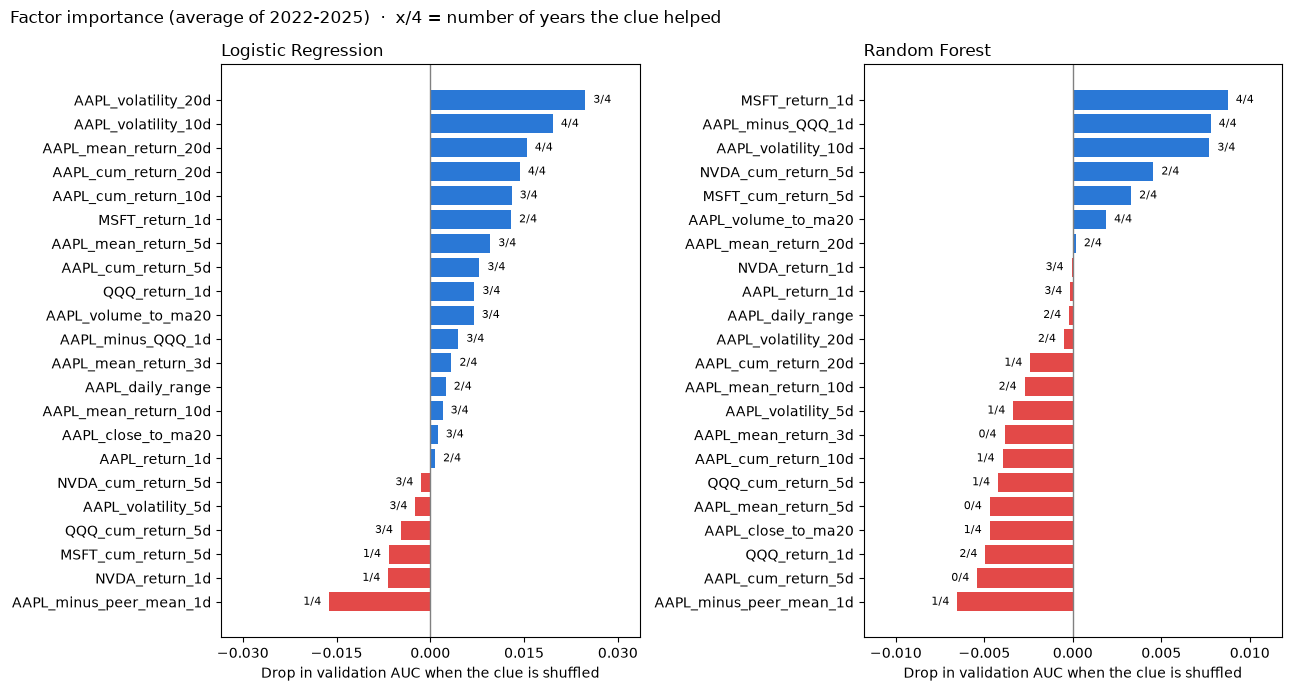

,model,clue,mean_importance,years_helped
13,Logistic Regression,AAPL_volatility_20d,0.0248,3
12,Logistic Regression,AAPL_volatility_10d,0.0196,4
6,Logistic Regression,AAPL_mean_return_20d,0.0154,4
2,Logistic Regression,AAPL_cum_return_20d,0.0143,4
1,Logistic Regression,AAPL_cum_return_10d,0.0130,3
39,Random Forest,MSFT_return_1d,0.0088,4
31,Random Forest,AAPL_minus_QQQ_1d,0.0078,4
34,Random Forest,AAPL_volatility_10d,0.0077,3
40,Random Forest,NVDA_cum_return_5d,0.0046,2
38,Random Forest,MSFT_cum_return_5d,0.0033,2


In [16]:
# Section 10: Factor importance - which of the 22 clues actually matter? (permutation importance)
from sklearn.metrics import roc_auc_score
from matplotlib.ticker import MaxNLocator
from src.features import FEATURE_SETS
from src.data import quarterly_split
from src.models import fit_logistic_regression, fit_random_forest

clues = FEATURE_SETS['C']            # all 22 clues
N_SHUFFLES = 10                      # shuffle each clue 10 times and average, to reduce luck
rng = np.random.default_rng(0)       # fixed randomness, so the result is reproducible

def importance_for_model(model, x_val, y_val):
    """How much worse does the model get on validation when ONE clue is scrambled?"""
    normal_auc = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])     # 1. normal score
    drops = {}
    for clue in clues:
        scores = []
        for _ in range(N_SHUFFLES):
            scrambled = x_val.copy()
            scrambled[clue] = rng.permutation(scrambled[clue].values)        # 2. shuffle just this clue
            scores.append(roc_auc_score(y_val, model.predict_proba(scrambled)[:, 1]))  # 3. score again
        drops[clue] = normal_auc - np.mean(scores)                           # 4. how much it dropped
    return drops

rows = []
for year in [2022, 2023, 2024, 2025]:
    splits_y = quarterly_split(features, year)
    x_train, y_train = splits_y['train'][clues], splits_y['train']['target_next_day_up']
    x_val, y_val = splits_y['validation'][clues], splits_y['validation']['target_next_day_up']   # test quarter NOT used

    lr = fit_logistic_regression(x_train, y_train, seed=42)
    for clue, drop in importance_for_model(lr, x_val, y_val).items():
        rows.append({'year': year, 'model': 'Logistic Regression', 'clue': clue, 'importance': drop})

    rf_drops = [importance_for_model(fit_random_forest(x_train, y_train, seed=s), x_val, y_val) for s in (0, 1, 2)]
    for clue in clues:                                                        # average the 3 RF seeds
        rows.append({'year': year, 'model': 'Random Forest', 'clue': clue,
                     'importance': np.mean([d[clue] for d in rf_drops])})
    print(f"{year}: done")

importance = pd.DataFrame(rows)
summary = (importance.groupby(['model', 'clue'])['importance']
           .agg(mean_importance='mean', years_helped=lambda x: int((x > 0).sum()))
           .reset_index())

# Chart: one panel per model, clues sorted from most to least important
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, model_name in zip(axes, ['Logistic Regression', 'Random Forest']):
    d = summary[summary.model == model_name].sort_values('mean_importance')
    colours = ['#2a78d6' if v > 0 else '#e34948' for v in d['mean_importance']]   # blue = helped, red = didn't
    ax.barh(d['clue'], d['mean_importance'], color=colours)
    ax.axvline(0, color='grey', linewidth=1)
    span = d['mean_importance'].abs().max()
    ax.set_xlim(-span * 1.35, span * 1.35)                                    # room for the x/4 labels
    ax.xaxis.set_major_locator(MaxNLocator(5))
    for y, (v, k) in enumerate(zip(d['mean_importance'], d['years_helped'])):
        ax.text(v, y, f"  {k}/4 " if v >= 0 else f" {k}/4  ", va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    ax.set_title(model_name, loc='left')
    ax.set_xlabel('Drop in validation AUC when the clue is shuffled')
fig.suptitle('Factor importance (average of 2022-2025)  ·  x/4 = number of years the clue helped', x=0.01, ha='left')
plt.tight_layout()
plt.show()

# Top 5 clues for each model
summary.sort_values(['model', 'mean_importance'], ascending=[True, False]).groupby('model').head(5).round(4)

In [17]:
# Step 10b: the four years behind the chart (top 5 clues per model + the worst one)
show = summary.sort_values('mean_importance', ascending=False).groupby('model').head(5)[['model', 'clue']]
show = pd.concat([show, pd.DataFrame({'model': ['Logistic Regression', 'Random Forest'],
                                      'clue': 'AAPL_minus_peer_mean_1d'})]).drop_duplicates()

by_year = importance.merge(show).pivot_table(index=['model', 'clue'], columns='year', values='importance')
by_year['average'] = by_year.mean(axis=1)
by_year['years helped'] = (by_year[[2022, 2023, 2024, 2025]] > 0).sum(axis=1).astype(str) + '/4'
by_year.sort_values(['model', 'average'], ascending=[True, False]).round(4)

year                                           2022    2023    2024    2025  \
model               clue                                                      
Logistic Regression AAPL_volatility_20d      0.0366  0.0422 -0.0122  0.0325   
                    AAPL_volatility_10d      0.0024  0.0081  0.0589  0.0090   
                    AAPL_mean_return_20d     0.0264  0.0068  0.0124  0.0162   
                    AAPL_cum_return_20d      0.0044  0.0016  0.0040  0.0473   
                    AAPL_cum_return_10d      0.0193  0.0262  0.0095 -0.0028   
                    AAPL_minus_peer_mean_1d -0.0596  0.0035 -0.0032 -0.0054   
Random Forest       MSFT_return_1d           0.0044  0.0241  0.0055  0.0010   
                    AAPL_minus_QQQ_1d        0.0072  0.0068  0.0108  0.0064   
                    AAPL_volatility_10d      0.0084 -0.0016  0.0217  0.0025   
                    NVDA_cum_return_5d       0.0043 -0.0145 -0.0042  0.0326   
                    MSFT_cum_return_5d       0.0128 -0.0008 -0.0003  0.0014   
                    AAPL_minus_peer_mean_1d -0.0028  0.0114 -0.0047 -0.0300   

year                                         average years helped  
model               clue                                           
Logistic Regression AAPL_volatility_20d       0.0248          3/4  
                    AAPL_volatility_10d       0.0196          4/4  
                    AAPL_mean_return_20d      0.0154          4/4  
                    AAPL_cum_return_20d       0.0143          4/4  
                    AAPL_cum_return_10d       0.0130          3/4  
                    AAPL_minus_peer_mean_1d  -0.0162          1/4  
Random Forest       MSFT_return_1d            0.0088          4/4  
                    AAPL_minus_QQQ_1d         0.0078          4/4  
                    AAPL_volatility_10d       0.0077          3/4  
                    NVDA_cum_return_5d        0.0046          2/4  
                    MSFT_cum_return_5d        0.0033          2/4  
                    AAPL_minus_peer_mean_1d  -0.0065          1/4